# Continuing the search over alternative scaling ratios

This notebook extends the non-golden ratio search by testing several candidate families on the same search window. The goal is to compare which alternative ratios produce the smallest values of the self-similarity functional and to record the strongest candidates found in each family.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pattern_search_common import (
    candidate_summary_entries,
    metallic_mean,
    periodic_continued_fraction,
    plot_patches,
    plot_ratio_comparison,
    plot_search_result,
    print_candidate_summary,
    search_over_ratios,
)

plt.rcParams['figure.dpi'] = 120


The notebook uses the shared utilities from `pattern_search_common.py`. In particular, `search_over_ratios` runs the search for an arbitrary finite family of ratios, while `candidate_summary_entries` and `print_candidate_summary` provide compact summaries of the best candidates found in each family.

In [2]:
BOUNDS = (-1.6, 0.4, -0.9, 0.9)
SEARCH_BOUNDS = (-1.05, -0.55, -0.35, 0.35)
N = 320
MAX_ITER = 200
R0 = 0.18
M = 3
PATCH_SIZE = 40
ANGLE_SAMPLES = 16
GRID_SHAPE = (17, 17)


All sections below use the same search window and the same discretization parameters. This keeps the comparisons direct: when one ratio obtains a smaller best score than another, the two values are computed under the same numerical conditions.

## Family 1: a first non-golden comparison set

In [3]:
family_one_ratios = [
    ('silver', metallic_mean(2)),
    ('bronze', metallic_mean(3)),
    ('tin', metallic_mean(4)),
    ('periodic_[1,2]', periodic_continued_fraction((1, 2))),
]

family_one = search_over_ratios(
    BOUNDS,
    SEARCH_BOUNDS,
    N,
    MAX_ITER,
    R0,
    family_one_ratios,
    m=M,
    patch_size=PATCH_SIZE,
    angle_samples=ANGLE_SAMPLES,
    grid_shape=GRID_SHAPE,
)

print_candidate_summary(family_one['results'])
family_one_best = family_one['results'][0]
print('\nBest ratio in Family 1:', family_one_best['name'])


periodic_[1,2] ratio = 1.366025 best center = (-0.8, 0.0) best score = 0.03269 sampled local minima = 11
silver ratio = 2.414214 best center = (-0.8, 0.0) best score = 0.042416 sampled local minima = 7
bronze ratio = 3.302776 best center = (-0.76875, 0.0) best score = 0.043503 sampled local minima = 5
tin ratio = 4.236068 best center = (-0.76875, 0.0) best score = 0.043796 sampled local minima = 5

Best ratio in Family 1: periodic_[1,2]


This first family reproduces the initial non-golden search. It compares three metallic means and one periodic continued-fraction ratio. The best score in this family gives a first indication of which non-golden scaling law most closely matches the current search window.

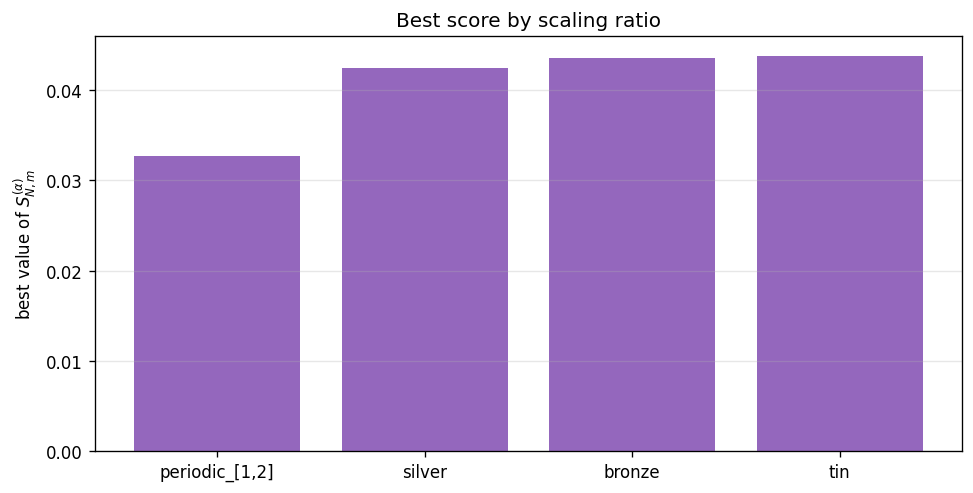

In [4]:
plot_ratio_comparison(family_one['results'])
plt.show()


## Family 2: a broader metallic-mean search

In [5]:
family_two_ratios = [(f'metallic_{k}', metallic_mean(k)) for k in range(2, 7)]

family_two = search_over_ratios(
    BOUNDS,
    SEARCH_BOUNDS,
    N,
    MAX_ITER,
    R0,
    family_two_ratios,
    m=M,
    patch_size=PATCH_SIZE,
    angle_samples=ANGLE_SAMPLES,
    grid_shape=GRID_SHAPE,
)

print_candidate_summary(family_two['results'])
family_two_best = family_two['results'][0]
print('\nBest ratio in Family 2:', family_two_best['name'])


metallic_2 ratio = 2.414214 best center = (-0.8, 0.0) best score = 0.042416 sampled local minima = 7
metallic_3 ratio = 3.302776 best center = (-0.76875, 0.0) best score = 0.043503 sampled local minima = 5
metallic_4 ratio = 4.236068 best center = (-0.76875, 0.0) best score = 0.043796 sampled local minima = 5
metallic_5 ratio = 5.192582 best center = (-0.76875, 0.0) best score = 0.043986 sampled local minima = 5
metallic_6 ratio = 6.162278 best center = (-0.76875, 0.0) best score = 0.044128 sampled local minima = 5

Best ratio in Family 2: metallic_2


This section broadens the metallic-mean search to the finite set
$$
\sigma_k = \frac{k+\sqrt{k^2+4}}{2}, \qquad 2 \leq k \leq 6.
$$
It tests whether the preference seen in the first family persists when the metallic-mean class is enlarged.

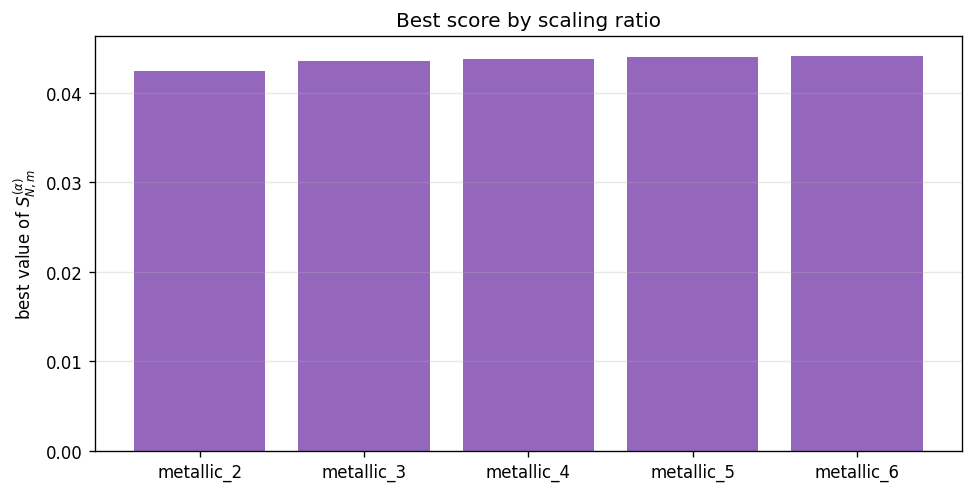

In [6]:
plot_ratio_comparison(family_two['results'])
plt.show()


## Family 3: periodic continued fractions

In [7]:
family_three_ratios = [
    ('periodic_[1,2]', periodic_continued_fraction((1, 2))),
    ('periodic_[1,3]', periodic_continued_fraction((1, 3))),
    ('periodic_[2,3]', periodic_continued_fraction((2, 3))),
    ('periodic_[1,1,2]', periodic_continued_fraction((1, 1, 2))),
    ('periodic_[2,2,1]', periodic_continued_fraction((2, 2, 1))),
]

family_three = search_over_ratios(
    BOUNDS,
    SEARCH_BOUNDS,
    N,
    MAX_ITER,
    R0,
    family_three_ratios,
    m=M,
    patch_size=PATCH_SIZE,
    angle_samples=ANGLE_SAMPLES,
    grid_shape=GRID_SHAPE,
)

print_candidate_summary(family_three['results'])
family_three_best = family_three['results'][0]
print('\nBest ratio in Family 3:', family_three_best['name'])


periodic_[1,3] ratio = 1.263763 best center = (-0.8, 0.0) best score = 0.029201 sampled local minima = 9
periodic_[1,2] ratio = 1.366025 best center = (-0.8, 0.0) best score = 0.03269 sampled local minima = 11
periodic_[1,1,2] ratio = 1.720759 best center = (-0.8, 0.0) best score = 0.038662 sampled local minima = 13
periodic_[2,3] ratio = 2.290994 best center = (-0.8, 0.0) best score = 0.041954 sampled local minima = 7
periodic_[2,2,1] ratio = 2.369924 best center = (-0.8, 0.0) best score = 0.042258 sampled local minima = 7

Best ratio in Family 3: periodic_[1,3]


This section tests a second source of non-golden ratios: quadratic irrationals defined by periodic continued fractions. Such ratios are natural candidates whenever one expects scaling laws related to periodic combinatorics.

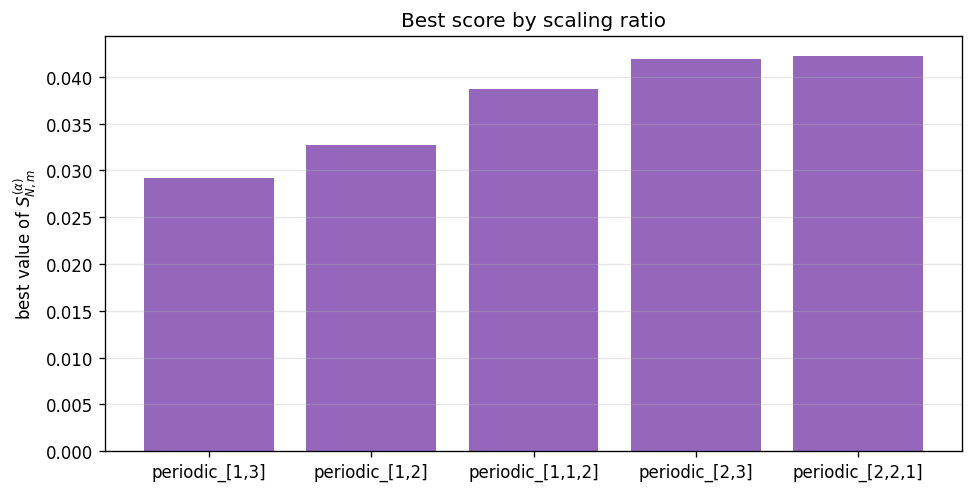

In [8]:
plot_ratio_comparison(family_three['results'])
plt.show()


## Family 4: a coarse interval scan

In [9]:
family_four_ratios = [(f'alpha_{alpha:.2f}', alpha) for alpha in (1.25, 1.35, 1.50, 1.75, 2.00, 2.50, 3.00, 4.00)]

family_four = search_over_ratios(
    BOUNDS,
    SEARCH_BOUNDS,
    N,
    MAX_ITER,
    R0,
    family_four_ratios,
    m=M,
    patch_size=PATCH_SIZE,
    angle_samples=ANGLE_SAMPLES,
    grid_shape=GRID_SHAPE,
)

print_candidate_summary(family_four['results'])
family_four_best = family_four['results'][0]
print('\nBest ratio in Family 4:', family_four_best['name'])


alpha_1.25 ratio = 1.25 best center = (-0.8, 0.0) best score = 0.028634 sampled local minima = 10
alpha_1.35 ratio = 1.35 best center = (-0.8, 0.0) best score = 0.032208 sampled local minima = 11
alpha_1.50 ratio = 1.5 best center = (-0.8, 0.0) best score = 0.035818 sampled local minima = 11
alpha_1.75 ratio = 1.75 best center = (-0.8, 0.0) best score = 0.038925 sampled local minima = 13
alpha_2.00 ratio = 2.0 best center = (-0.8, 0.0) best score = 0.040592 sampled local minima = 7
alpha_2.50 ratio = 2.5 best center = (-0.8, 0.0) best score = 0.0427 sampled local minima = 7
alpha_3.00 ratio = 3.0 best center = (-0.76875, 0.0) best score = 0.04335 sampled local minima = 5
alpha_4.00 ratio = 4.0 best center = (-0.76875, 0.0) best score = 0.04374 sampled local minima = 5

Best ratio in Family 4: alpha_1.25


The interval scan is not tied to a specific arithmetic family. It gives a coarse probe of how the functional behaves when one searches over a small discrete sample of real ratios. This can be used to suggest where a finer search should be performed next.

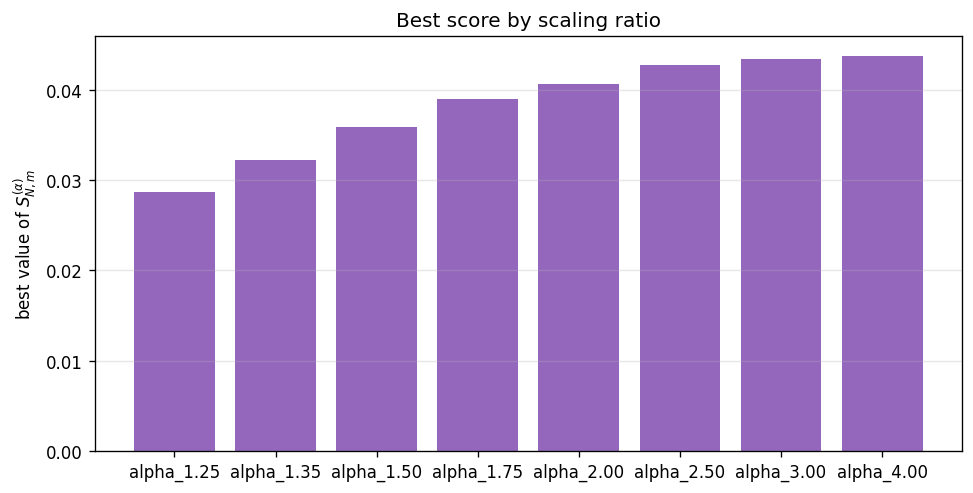

In [10]:
plot_ratio_comparison(family_four['results'])
plt.show()


## Consolidated candidate summary

In [11]:
family_summaries = {
    'family_one': candidate_summary_entries(family_one['results'], limit=2),
    'family_two': candidate_summary_entries(family_two['results'], limit=2),
    'family_three': candidate_summary_entries(family_three['results'], limit=2),
    'family_four': candidate_summary_entries(family_four['results'], limit=2),
}

for family_name, entries in family_summaries.items():
    print(family_name)
    for entry in entries:
        print(' ', entry)


family_one
  {'name': 'periodic_[1,2]', 'ratio': 1.3660254037844386, 'center': (-0.8, 0.0), 'score': 0.032690037819788915, 'local_minima': 11}
  {'name': 'silver', 'ratio': 2.414213562373095, 'center': (-0.8, 0.0), 'score': 0.04241620213597493, 'local_minima': 7}
family_two
  {'name': 'metallic_2', 'ratio': 2.414213562373095, 'center': (-0.8, 0.0), 'score': 0.04241620213597493, 'local_minima': 7}
  {'name': 'metallic_3', 'ratio': 3.302775637731995, 'center': (-0.76875, 0.0), 'score': 0.04350286240200262, 'local_minima': 5}
family_three
  {'name': 'periodic_[1,3]', 'ratio': 1.2637626158259734, 'center': (-0.8, 0.0), 'score': 0.02920053684837689, 'local_minima': 9}
  {'name': 'periodic_[1,2]', 'ratio': 1.3660254037844386, 'center': (-0.8, 0.0), 'score': 0.032690037819788915, 'local_minima': 11}
family_four
  {'name': 'alpha_1.25', 'ratio': 1.25, 'center': (-0.8, 0.0), 'score': 0.028633567652667773, 'local_minima': 10}
  {'name': 'alpha_1.35', 'ratio': 1.35, 'center': (-0.8, 0.0), 'score'

This cell collects the strongest candidates from each tested family. These are the entries that should be mirrored back into the shared helper module as a compact summary of the current experimental findings.

Overall best candidate family winner: alpha_1.25


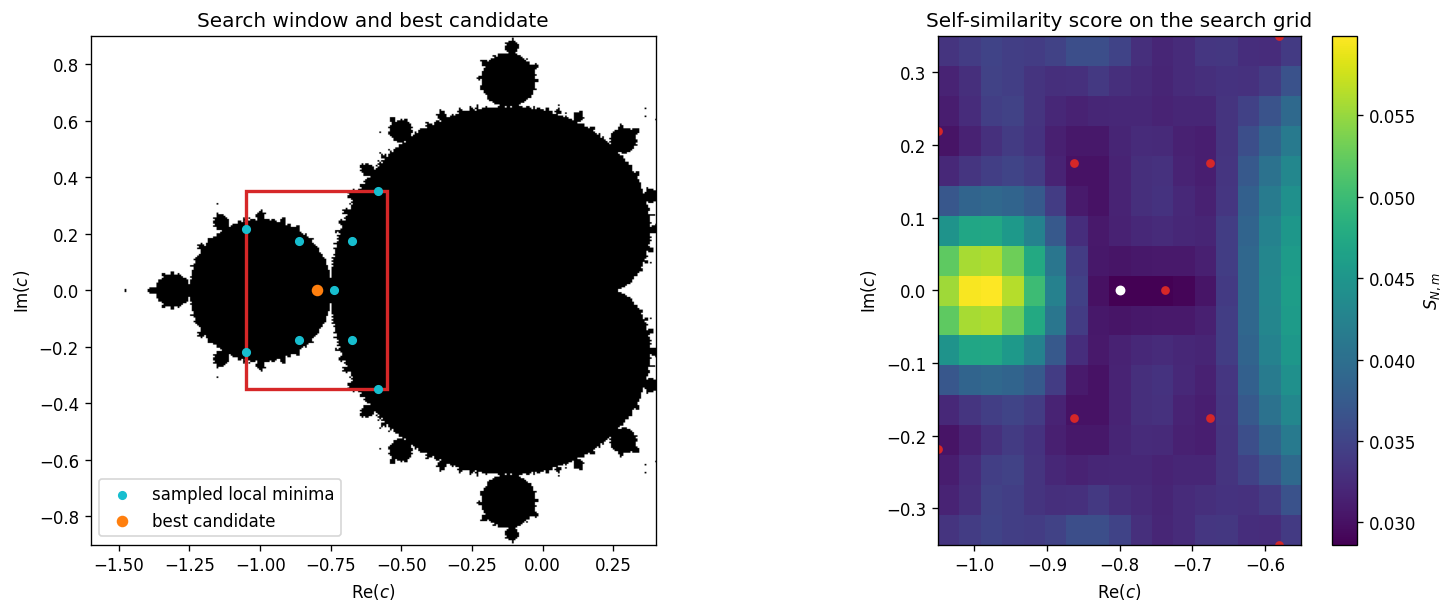

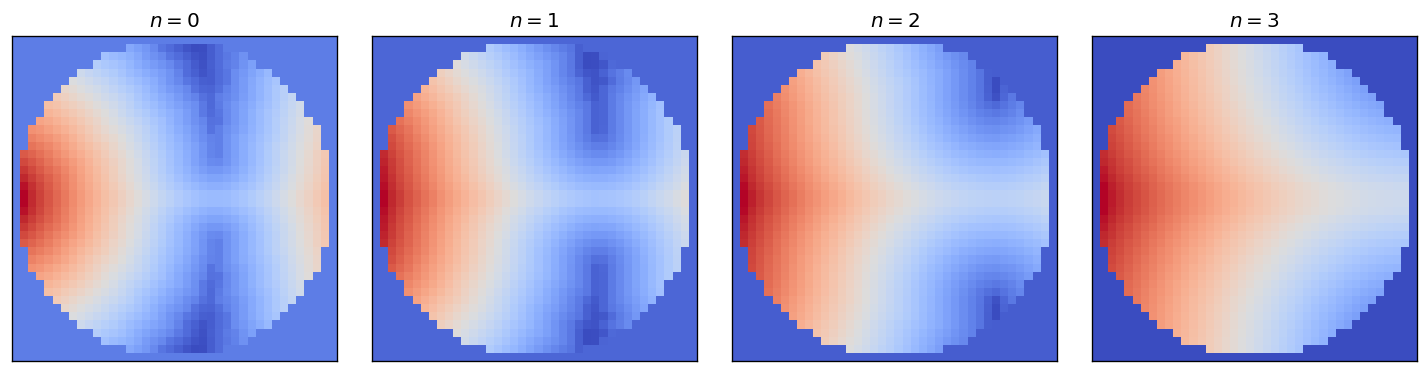

In [12]:
all_best_results = [family_one_best, family_two_best, family_three_best, family_four_best]
all_best_results.sort(key=lambda item: item['best']['score'])
overall_best = all_best_results[0]
print('Overall best candidate family winner:', overall_best['name'])

plot_search_result(
    family_one['indicator'],
    BOUNDS,
    SEARCH_BOUNDS,
    overall_best['grid_xs'],
    overall_best['grid_ys'],
    overall_best['score_grid'],
    overall_best['best'],
    overall_best['local_minima'],
)
plt.show()

plot_patches(overall_best['best'], M)
plt.show()


The final figures display the spatial score distribution and the normalized patches for the strongest candidate found across all tested non-golden families in this notebook. This remains a coarse exploratory computation, but it now compares several distinct ratio classes rather than only a single small family.